In [1]:
import io
import time
import urllib.request
import warnings
import zipfile
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, ConfusionMatrixDisplay, f1_score, log_loss,
    precision_score, PrecisionRecallDisplay, recall_score,
    RocCurveDisplay, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 8, 10, 12], dtype=float)

In [3]:
F0 = y.mean()
pred0 = np.full_like(y, F0)
residual0 = y - pred0
MSE = np.mean((y - pred0) ** 2)

In [4]:
tree1 = DecisionTreeRegressor(max_depth=1)
tree1.fit(x.reshape(-1, 1), residual0)


DecisionTreeRegressor(max_depth=1)

[Text(0.5, 0.75, 'distance <= 1.5\nsamples = 4\nvalue = 0.0'),
 Text(0.25, 0.25, 'samples = 1\nvalue = -6.0'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'samples = 3\nvalue = 2.0'),
 Text(0.625, 0.5, '  False')]

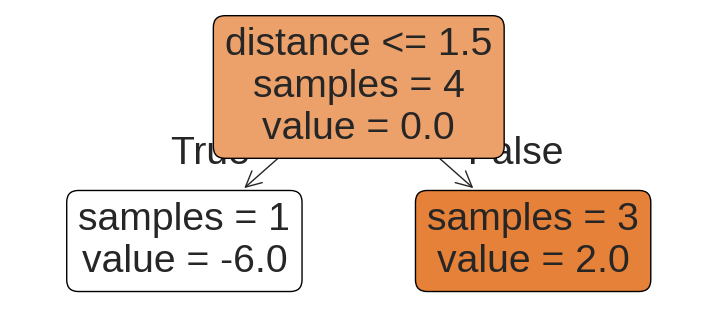

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_tree(tree1, feature_names=["distance"], filled=True, rounded=True,
          impurity=False, precision=2, ax=ax)

In [6]:
correction1 = tree1.predict(x.reshape(-1, 1))

In [7]:
learning_rate = 0.5
pred1 = pred0 + learning_rate * correction1

In [8]:
pred1

array([5., 9., 9., 9.])

In [9]:
MSE = np.mean((y - pred1) ** 2)

In [10]:
residual1 = y - pred1
residual1

array([-3., -1.,  1.,  3.])

In [14]:
RANDOM_STATE = 42
def fit_simple_gradient_boosting(X, y, n_trees=30, learning_rate=0.1, max_depth=1):
    baseline = y.mean()
    predictions = np.full(len(y), baseline, dtype=float)

    trees = []
    mse_history = []

    for round_number in range(n_trees):
        residuals = y - predictions
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
        tree.fit(X, residuals)

        corrections = tree.predict(X)
        predictions += learning_rate * corrections

        trees.append(tree)
        mse_history.append(np.mean((y - predictions) ** 2))
    return baseline, trees, mse_history

def predict_simple_boosting(X, baseline, trees, learning_rate):
    predictions = np.full(X.shape[0], baseline, dtype=float)
    for tree in trees:
        predictions += learning_rate * tree.predict(X)
    return predictions

In [11]:
rng = np.random.default_rng(RANDOM_STATE)
X_curve = np.linspace(0, 8, 80).reshape(-1, 1)
y_curve = 2 + 0.55 * X_curve[:, 0]
y_curve += 1.8 * np.sin(1.25 * X_curve[:, 0])
y_curve += rng.normal(0, 0.35, len(y_curve))

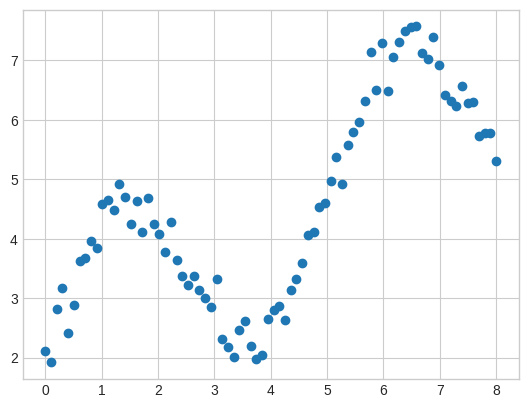

In [12]:
plt.scatter(X_curve, y_curve)

In [15]:
eta = 0.2
baseline, trees, mse_history = fit_simple_gradient_boosting(X_curve, y_curve, n_trees=100, learning_rate=eta)


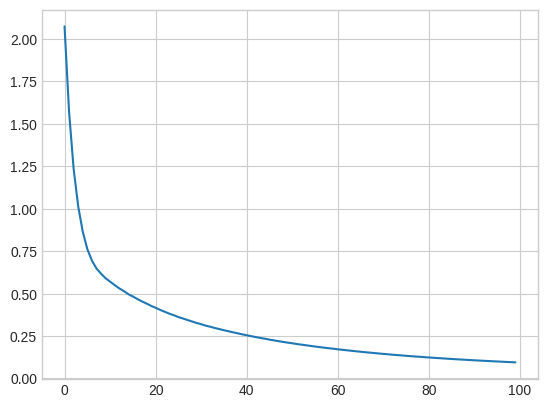

In [ ]:
plt.plot(range(len(trees)), mse_history)

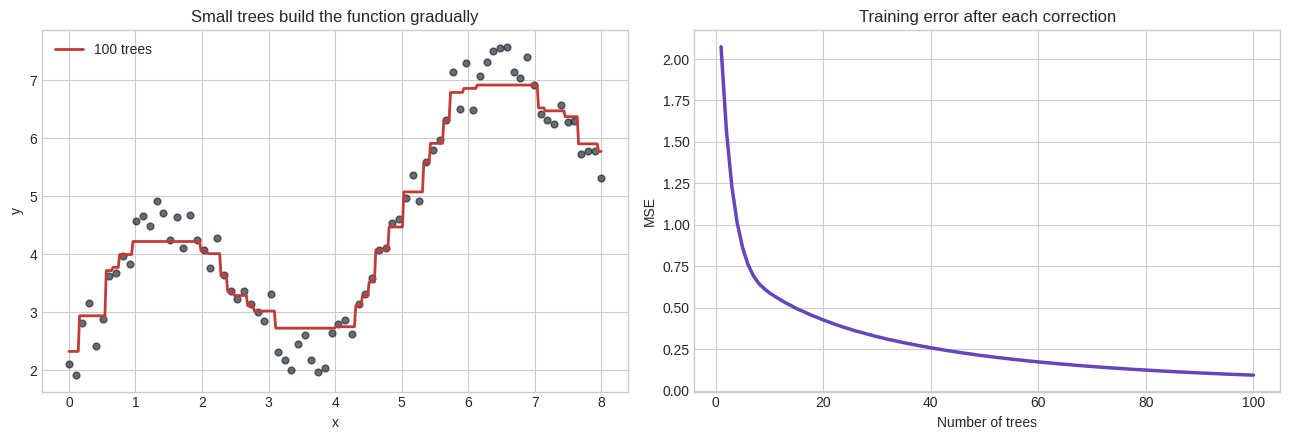

In [16]:
grid = np.linspace(0, 8, 400).reshape(-1, 1)
stages = [100]
colors = ["#c43b36", "#a96700", "#1769aa", "#087f6b"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(X_curve[:, 0], y_curve, s=24,
                alpha=0.65, color="#17202a")

for count, color in zip(stages, colors):
    stage_pred = predict_simple_boosting(
        grid, baseline, trees[:count], eta
    )
    axes[0].plot(grid[:, 0], stage_pred, color=color,
                 linewidth=2, label=f"{count} trees")

axes[0].set(title="Small trees build the function gradually",
            xlabel="x", ylabel="y")
axes[0].legend()

axes[1].plot(range(1, len(mse_history[:count]) + 1), mse_history[:count],
             color="#6346b8", linewidth=2.5)
axes[1].set(title="Training error after each correction",
            xlabel="Number of trees", ylabel="MSE")
plt.tight_layout()
plt.show()

In [17]:
sk_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=eta, max_depth=1, loss='squared_error', random_state=RANDOM_STATE)
sk_reg.fit(X_curve, y_curve)


GradientBoostingRegressor(learning_rate=0.2, max_depth=1, random_state=42)

In [18]:
our_pred = predict_simple_boosting(X_curve, baseline, trees, eta)
sk_pred = sk_reg.predict(X_curve)

In [19]:
np.max(np.abs(our_pred - sk_pred))

np.float64(0.0)

In [20]:
our_loss = np.mean((y_curve - our_pred) ** 2)
sk_loss = np.mean((y_curve - sk_pred) ** 2)
print(our_loss, sk_loss)

0.09493848209756635 0.09493848209756635


In [30]:
x_class = np.arange(1, 9, dtype=float)
y_class = np.array([1, 0, 1, 1, 0, 0, 1, 0])

In [32]:
p0 = y_class.mean()
F0_class = np.log(p0 / (1 - p0)) # logits or log odds
prob0 = np.full(len(y_class), p0)

In [34]:
pseudo_residuals = y_class - prob0
pseudo_residuals

array([ 0.5, -0.5,  0.5,  0.5, -0.5, -0.5,  0.5, -0.5])

In [35]:
display(pd.DataFrame({
    "feature rank": x_class,
    "actual class": y_class,
    "initial raw score": F0_class,
    "initial probability": prob0,
    "pseudo-residual (y - p)": pseudo_residuals,
}))

print(f"Initial probability: {p0:.1f}")
print(f"Initial raw score: {F0_class:.1f}")
print(f"Initial log loss: {log_loss(y_class, prob0):.4f}")

,feature rank,actual class,initial raw score,initial probability,pseudo-residual (y - p)
0,1.0,1,0.0,0.5,0.5
1,2.0,0,0.0,0.5,-0.5
2,3.0,1,0.0,0.5,0.5
3,4.0,1,0.0,0.5,0.5
4,5.0,0,0.0,0.5,-0.5
5,6.0,0,0.0,0.5,-0.5
6,7.0,1,0.0,0.5,0.5
7,8.0,0,0.0,0.5,-0.5


Initial probability: 0.5
Initial raw score: 0.0
Initial log loss: 0.6931


In [36]:
class_tree = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
class_tree.fit(x_class.reshape(-1, 1), pseudo_residuals)


DecisionTreeRegressor(max_depth=1, random_state=42)

In [39]:
leaf_ids = class_tree.apply(x_class.reshape(-1, 1))

In [40]:
leaf_ids

array([1, 1, 1, 1, 2, 2, 2, 2])

[Text(0.5, 0.75, 'distance <= 4.5\nsamples = 8\nvalue = 0.0'),
 Text(0.25, 0.25, 'samples = 4\nvalue = 0.25'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'samples = 4\nvalue = -0.25'),
 Text(0.625, 0.5, '  False')]

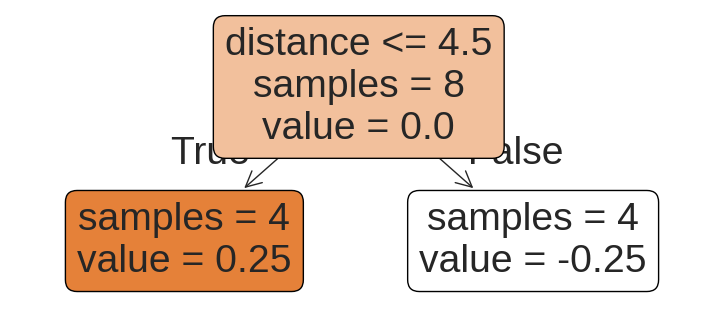

In [38]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_tree(class_tree, feature_names=["distance"], filled=True, rounded=True,
          impurity=False, precision=2, ax=ax)

In [45]:
leaf_update = {}
for leaf in np.unique(leaf_ids):
    mask = leaf_ids == leaf
    positive_rate = y_class[mask].mean()
    leaf_score = np.log(positive_rate / (1 - positive_rate))
    leaf_update[leaf] = leaf_score - F0_class

In [50]:
gamma = np.array([leaf_update[leaf] for leaf in leaf_ids])
eta_class = 0.5
F1_class = F0_class + eta_class * gamma #boosting update step
prob1 = 1 / (1 + np.exp(-F1_class))
prob1

array([0.6339746, 0.6339746, 0.6339746, 0.6339746, 0.3660254, 0.3660254,
       0.3660254, 0.3660254])

In [51]:

display(pd.DataFrame({
    "feature rank": x_class,
    "actual": y_class,
    "pseudo-residual": pseudo_residuals,
    "leaf update": gamma,
    "new raw score": F1_class,
    "new probability": prob1,
}))

print(f"Chosen split: x <= {class_tree.tree_.threshold[0]:.1f}")
print(f"Log loss before: {log_loss(y_class, prob0):.4f}")
print(f"Log loss after:  {log_loss(y_class, prob1):.4f}")

,feature rank,actual,pseudo-residual,leaf update,new raw score,new probability
0,1.0,1,0.5,1.098612,0.549306,0.633975
1,2.0,0,-0.5,1.098612,0.549306,0.633975
2,3.0,1,0.5,1.098612,0.549306,0.633975
3,4.0,1,0.5,1.098612,0.549306,0.633975
4,5.0,0,-0.5,-1.098612,-0.549306,0.366025
5,6.0,0,-0.5,-1.098612,-0.549306,0.366025
6,7.0,1,0.5,-1.098612,-0.549306,0.366025
7,8.0,0,-0.5,-1.098612,-0.549306,0.366025


Chosen split: x <= 4.5
Log loss before: 0.6931
Log loss after:  0.5931


In [52]:
DATA_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
DATA_PATH = Path("data/bank-full.csv")

if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading the UCI Bank Marketing dataset...")

    with urllib.request.urlopen(DATA_URL) as response:
        outer_bytes = response.read()

    with zipfile.ZipFile(io.BytesIO(outer_bytes)) as outer_zip:
        inner_bytes = outer_zip.read("bank.zip")

    with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner_zip:
        DATA_PATH.write_bytes(inner_zip.read("bank-full.csv"))

    print("Dataset downloaded.")
else:
    print("Using the existing local dataset.")

bank = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", bank.shape)
bank.head()

Dataset downloaded.
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [53]:
y_bank = (bank["y"] == "yes").astype(int)
X_bank = bank.drop(columns=["y", "duration"])
print("Positive subscriptions:", y_bank.sum())
print("Positive rate:", f"{y_bank.mean():.1%}")
print("\nFeature types:")
print(X_bank.dtypes.value_counts())

Positive subscriptions: 5289
Positive rate: 11.7%

Feature types:
object    9
int64     6
Name: count, dtype: int64


In [54]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bank,
    y_bank,
    test_size=0.25,
    stratify=y_bank,
    random_state=RANDOM_STATE,
)

In [56]:
categorical_columns = X_train.select_dtypes(include="object").columns
numeric_columns = X_train.select_dtypes(exclude="object").columns

In [58]:
numeric_columns

Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')

In [59]:
preprocessor = ColumnTransformer(
    [
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
        ("numeric", KNNImputer(), numeric_columns), # Replaced SimpleImputer with KNNImputer
    ],
    verbose_feature_names_out=False,
)

In [60]:
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

In [61]:
feature_names

array(['job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'age', 'balance', 'day', 'campaign', 'pdays',
       'previous'], dtype=object)

In [71]:
def metric_row(name, y_true, probability, fit_seconds=None, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "average_precision": average_precision_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "fit_seconds": fit_seconds,
    }



In [72]:
prior_model = DummyClassifier(strategy="prior")
prior_model.fit(X_train_ready, y_train)
prior_probability = prior_model.predict_proba(X_test_ready)[:, 1]


In [69]:
prior_probability

array([0.11699304, 0.11699304, 0.11699304, ..., 0.11699304, 0.11699304,
       0.11699304])

In [102]:
results = [
    metric_row("Prior baseline", y_test, prior_probability)
]

In [97]:
results

[{'model': 'Prior baseline',
  'accuracy': 0.8830399009112625,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'roc_auc': np.float64(0.5),
  'average_precision': np.float64(0.1169600990887375),
  'log_loss': 0.36082412824647864,
  'fit_seconds': None}]

In [75]:
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.5, max_depth=2, subsample=0.9, random_state=RANDOM_STATE)
start_time = time.perf_counter()
gb_model.fit(X_train_ready, y_train)
gb_fit_seconds = time.perf_counter() - start_time


In [98]:
gb_probability = gb_model.predict_proba(X_test_ready)[:, 1]
gb_prediction = (gb_probability >= 0.01).astype(int)

In [107]:
results.append(
    metric_row(
        "GB Classifier_th0.1",
        y_test,
        gb_probability,
        gb_fit_seconds,
        threshold=0.1
    )
)

In [108]:
pd.DataFrame(results).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc,average_precision,log_loss,fit_seconds
model,,,,,,,,
Prior baseline,0.883,0.000,0.000,0.000,0.500,0.117,0.361,NaN
GB Classifier_th0.5,0.895,0.628,0.254,0.362,0.799,0.445,0.286,15.891
GB Classifier_th0.3,0.890,0.536,0.423,0.473,0.799,0.445,0.286,15.891
GB Classifier_th0.1,0.768,0.292,0.694,0.411,0.799,0.445,0.286,15.891


In [94]:
gb_probability

array([0.04691293, 0.03924743, 0.03396927, ..., 0.10292193, 0.09217403,
       0.03307942])

In [109]:
!pip install xgboost

In [110]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=4,
    )


In [111]:
start_time = time.perf_counter()
xgb_model.fit(
    X_train_ready,
    y_train,
    eval_set=[
        (X_train_ready, y_train),
        (X_test_ready, y_test),
    ],
    verbose=False,
)
xgb_fit_seconds = time.perf_counter() - start_time

xgb_probability = xgb_model.predict_proba(X_test_ready)[:, 1]
xgb_prediction = (xgb_probability >= 0.5).astype(int)

results.append(
    metric_row(
        "XGBClassifier_th0.5",
        y_test,
        xgb_probability,
        xgb_fit_seconds,
    )
)

In [116]:
pd.DataFrame(results).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc,average_precision,log_loss,fit_seconds
model,,,,,,,,
Prior baseline,0.883,0.000,0.000,0.000,0.500,0.117,0.361,NaN
GB Classifier_th0.5,0.895,0.628,0.254,0.362,0.799,0.445,0.286,15.891
GB Classifier_th0.3,0.890,0.536,0.423,0.473,0.799,0.445,0.286,15.891
GB Classifier_th0.1,0.768,0.292,0.694,0.411,0.799,0.445,0.286,15.891
XGBClassifier_th0.5,0.896,0.655,0.233,0.344,0.805,0.468,0.281,12.429
XGBClassifier_th0.3,0.896,0.655,0.233,0.344,0.805,0.468,0.281,12.429
XGBClassifier_th0.30,0.891,0.544,0.421,0.475,0.805,0.468,0.281,12.429


In [115]:
xgb_probability = xgb_model.predict_proba(X_test_ready)[:, 1]
xgb_prediction = (xgb_probability >= 0.3).astype(int)

results.append(
    metric_row(
        "XGBClassifier_th0.30",
        y_test,
        xgb_probability,
        xgb_fit_seconds,
        threshold=0.3
    )
)